## **Mission 1 : Exploration et préparation des données**

### 1. Charger les données et effectuer une analyse exploratoire.

Chargement des données

In [18]:
import pandas as pd

In [19]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing(as_frame=True)

In [20]:
print(list(housing))

['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR']


In [21]:
# Aperçu des colonnes
housing.data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [22]:
housing.target.head()

,MedHouseVal
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422


In [23]:
housing.data.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


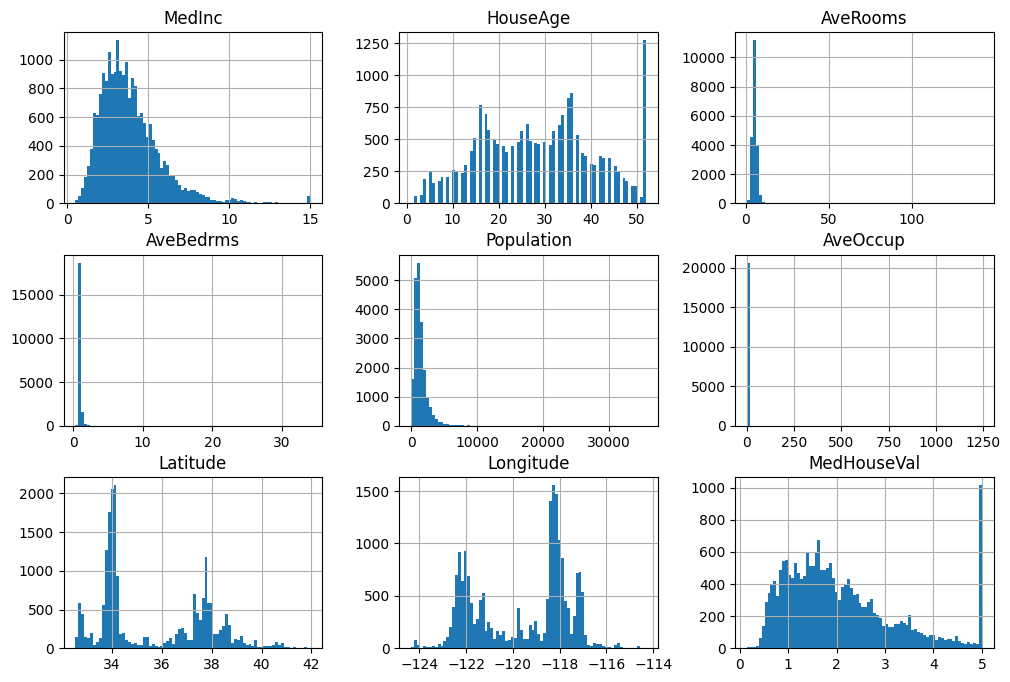

In [24]:
# Extract the combined DataFrame
import matplotlib.pyplot as plt
housing_df = housing.frame

# Display histograms for all numerical columns
housing_df.hist(bins=80, figsize=(12,8))
plt.show()

**Analyse exploratoire des données**

**Distribution des variables**

L'analyse des histogrammes révèle des comportements distincts selon les types de variables :


Variables numériques continues :

- MedInc (Revenu médian) : Distribution asymétrique à droite avec une concentration autour des valeurs moyennes (2-4). Quelques observations présentent des revenus nettement supérieurs, créant une longue queue à droite.
- MedHouseVal (Prix médian des maisons - variable cible) : Distribution avec une forte concentration entre 1 et 3 (en centaines de milliers de dollars). On observe un pic marqué à la valeur 5, indiquant un plafonnement artificiel des prix dans le dataset original. Cette censure à droite devra être prise en compte lors de la modélisation.

Variables démographiques et structurelles :

- HouseAge (Âge des maisons) : Distribution relativement uniforme sur toute la plage [0-50], suggérant une représentation équilibrée de différentes périodes de construction. La valeur maximale de 50 ans indique également un plafonnement.

- AveRooms, AveBedrms, AveOccup : Distributions fortement asymétriques avec une majorité écrasante de valeurs proches de zéro et quelques valeurs extrêmes très élevées. Ces outliers nécessiteront probablement un traitement (winsorisation, transformation log, ou suppression) pour éviter de biaiser les modèles.

- Population : Distribution très concentrée sur les faibles valeurs avec une longue queue, reflétant la présence de quelques zones très densément peuplées.

Variables géographiques :

- Latitude : Distribution multimodale avec plusieurs pics, correspondant aux principales zones urbaines de Californie (probablement Los Angeles, San Francisco, San Diego).
- Longitude : Distribution similaire reflétant la répartition géographique le long de la côte californienne.

**GEOSPATIAL PLOT**

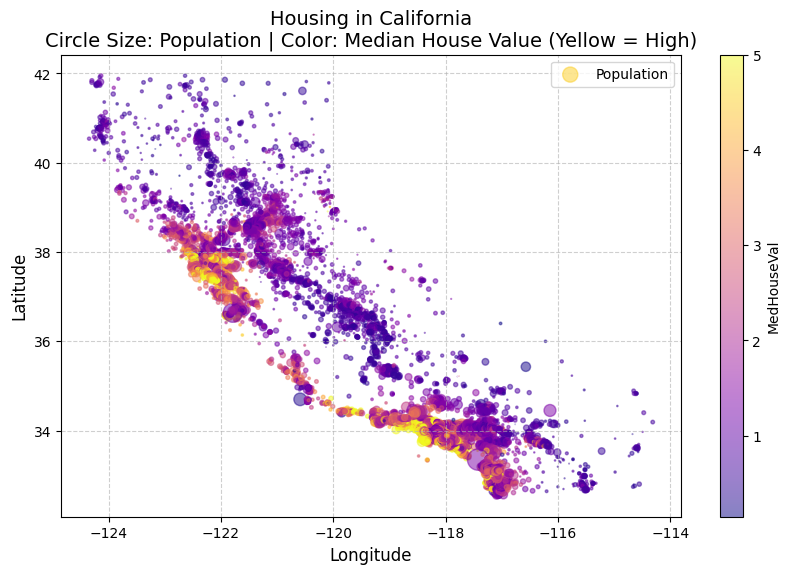

In [25]:
import matplotlib.pyplot as plt

housing_df_copy = housing_df.copy()
# Tracer le graphique

housing_df.plot(
    kind='scatter',
    x='Longitude',
    y='Latitude',
    alpha=0.5,
    s=housing_df['Population'] / 150,  # Adjust circle size
    label='Population',
    c='MedHouseVal',  # Color by median house value
    cmap='plasma',  # Yellow for the highest values
    colorbar=True,
    figsize=(10, 6)
)

# Adding title and labels
plt.title("Housing in California\nCircle Size: Population | Color: Median House Value (Yellow = High)", fontsize=14)
plt.xlabel("Longitude", fontsize=12)
plt.ylabel("Latitude", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

**Analyse géospatiale des prix immobiliers**

L'analyse géospatiale met en évidence deux facteurs déterminants pour les prix immobiliers : la proximité côtière et la densité démographique. Les régions situées près de l'océan présentent systématiquement des valeurs plus élevées, et cette tendance se renforce dans les zones à forte concentration de population.

**Recherche des corrélations**

Nous allons etudier les Corrélations des Variables avec la Variable Cible MedHouseVal

In [26]:
corr = housing_df.corr()
corr['MedHouseVal'].sort_values(ascending=True)

,MedHouseVal
Latitude,-0.144160
AveBedrms,-0.046701
Longitude,-0.045967
Population,-0.024650
AveOccup,-0.023737
HouseAge,0.105623
AveRooms,0.151948
MedInc,0.688075
MedHouseVal,1.000000


**Analyse des corrélations avec la variable cible (MedHouseVal)**

* Corrélation forte :

MedInc (0.688) : Le revenu médian présente la corrélation la plus élevée avec le prix des logements, confirmant que le pouvoir d'achat est le principal déterminant des valeurs immobilières.

* Corrélations positives faibles :

AveRooms (0.152) : Le nombre moyen de pièces montre une corrélation positive modeste avec les prix.

HouseAge (0.106) : L'âge des maisons présente une très faible corrélation positive, suggérant un impact limité sur les prix.

* Corrélations négatives faibles :

Latitude (-0.144) : Corrélation négative la plus marquée parmi les variables géographiques, indiquant une tendance à des prix légèrement plus bas dans les zones nordiques.

Longitude (-0.046), AveBedrms (-0.047), Population (-0.025), AveOccup (-0.024) : Ces variables présentent des corrélations quasi-nulles avec le prix, suggérant une influence négligeable dans une analyse univariée.

**Conclusion :**
Le revenu médian (MedInc) s'impose comme le prédicteur univarié le plus pertinent, tandis que les variables démographiques et structurelles montrent des relations linéaires très limitées avec la variable cible.

### 2. Identifier les valeurs manquantes ou aberrantes.

**Vérification des valeurs manquantes:**

La méthode .info() permet d'obtenir un aperçu rapide de la description des données

In [27]:
housing.data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB




*   Pas de données manquantes dans la base de données.
*  Toutes les variables sont numériques de type float.


**Vérifivation des valeurs aberrantes:**

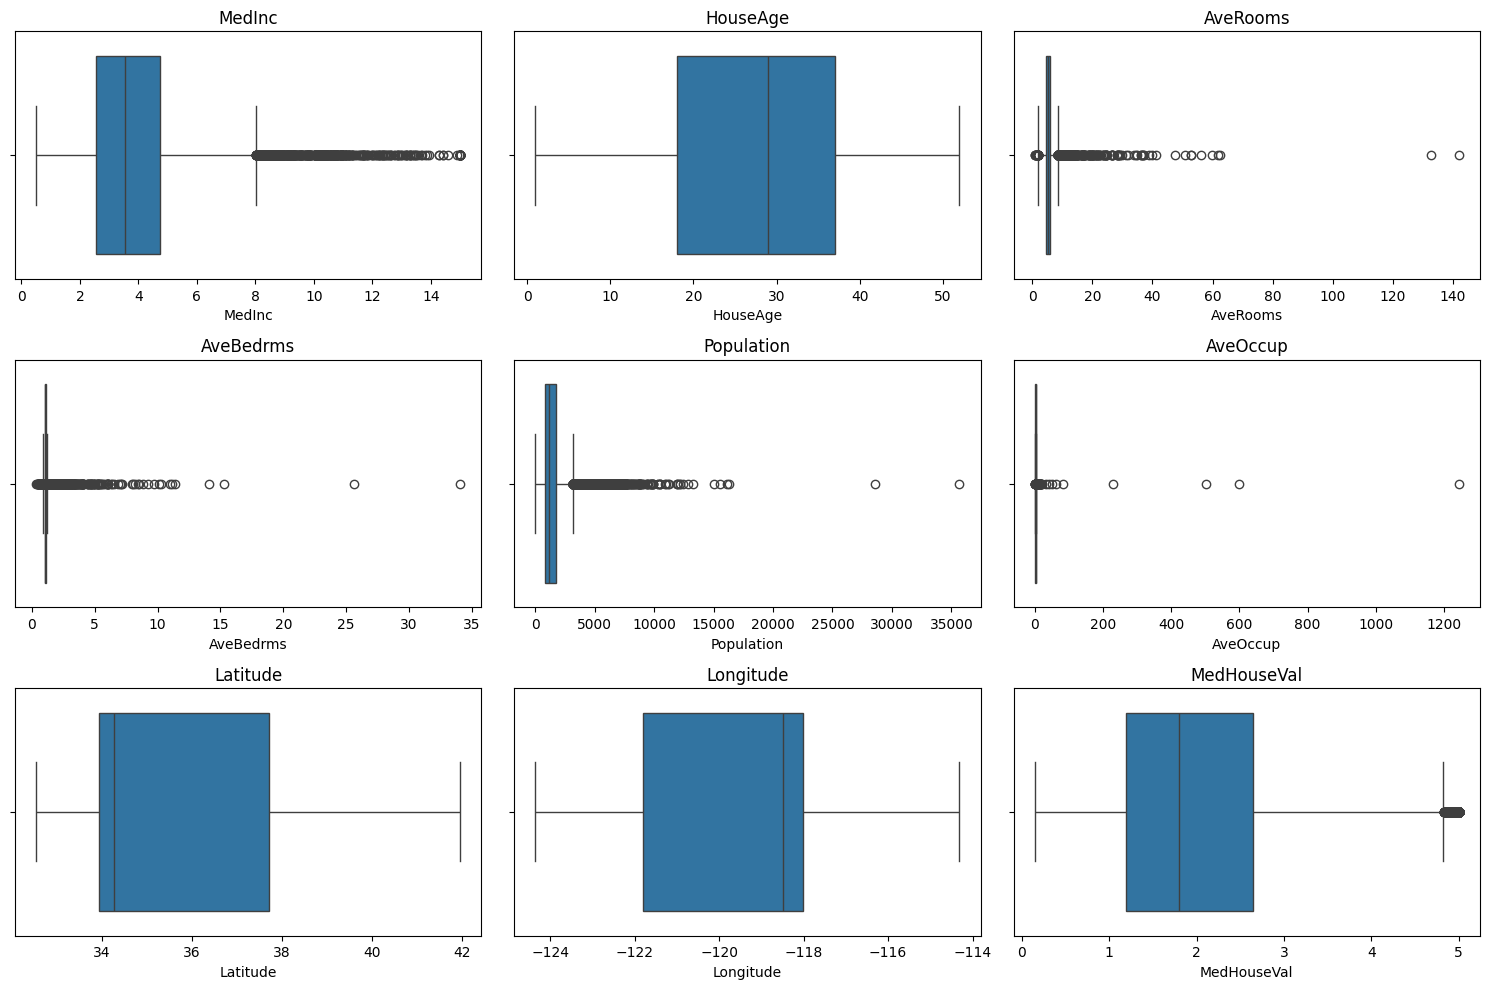

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

housing_df = housing.frame  # Combined DataFrame (features + target)

# Select numeric columns
numeric_columns = housing_df.select_dtypes(include=['float64', 'int']).columns
len_numeric_columns = len(numeric_columns)

# Initialize figure
fig = plt.figure(figsize=(15, 10))

# Set the number of columns for the plot
n_cols = 3

# Calculate the number of rows dynamically
n_plot_rows = (len_numeric_columns + n_cols - 1) // n_cols  # Ensure all columns fit

# Create boxplots
for i, column in enumerate(numeric_columns):
    ax = fig.add_subplot(n_plot_rows, n_cols, i + 1)
    sns.boxplot(x=housing_df[column], orient='h', ax=ax)
    ax.set_title(column)  # Add the column name as the title

# Adjust layout for better spacing
fig.tight_layout()

# Show the plots
plt.show()




**Détection des valeurs aberrantes (Outliers)**

L'analyse des boxplots révèle la présence d'outliers dans plusieurs variables, avec des degrés de sévérité variables :

* Variables avec outliers extrêmes :

AveRooms : Présence de nombreux outliers très éloignés (valeurs dépassant 100), avec quelques cas extrêmes autour de 140. La majorité des données se concentre entre 0 et 10.

Population : Distribution fortement asymétrique avec des valeurs extrêmes atteignant 35 000, alors que la boîte à moustaches indique une concentration massive sous 5 000 habitants.

AveOccup : Nombreux outliers s'étendant jusqu'à 1 200, avec une distribution normale concentrée près de zéro.

AveBedrms : Quelques outliers modérés atteignant 35, bien que la majorité des observations reste concentrée sous 5.

* Variables avec outliers modérés :

MedInc : Présence d'outliers au-delà de 10, la distribution principale s'étendant de 2 à 6.

* Variables sans outliers significatifs :

HouseAge : Distribution uniforme sans valeurs aberrantes visibles, avec un plafonnement à 50.

Latitude et Longitude : Pas d'outliers, distributions reflétant naturellement la géographie de la Californie.

MedHouseVal : Une seule valeur aberrante visible à 5 (effet de censure déjà identifié).

**Conclusion :** Les variables AveRooms, Population , AveOccup , AveBedrms et MedInc nécessiteront un traitement spécifique

In [29]:
# Fonction pour détecter les outliers avec l'IQR
def detect_outliers_iqr(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)  # Premier quartile
    Q3 = dataframe[column].quantile(0.75)  # Troisième quartile
    IQR = Q3 - Q1  # Intervalle interquartile
    lower_bound = Q1 - 1.5 * IQR  # Limite inférieure
    upper_bound = Q3 + 1.5 * IQR  # Limite supérieure
    return dataframe[(dataframe[column] < lower_bound) | (dataframe[column] > upper_bound)]

# Initialiser le compteur d'outliers
total_outliers = 0

# Vérifier les outliers pour chaque colonne dans housing_df
for column in housing_df.columns:
    outliers = detect_outliers_iqr(housing_df , column)
    count_outliers = len(outliers)
    total_outliers += count_outliers
    print(f"Colonne: {column} | Nombre d'outliers: {count_outliers}")

# Calcul du pourcentage total des outliers
percentage_outliers = (total_outliers / (housing_df.shape[0] * len(housing_df.columns))) * 100
print(f"\nNombre total d'outliers détectés: {total_outliers}")
print(f"Pourcentage d'outliers par rapport au total: {percentage_outliers:.2f}%")


Colonne: MedInc | Nombre d'outliers: 681
Colonne: HouseAge | Nombre d'outliers: 0
Colonne: AveRooms | Nombre d'outliers: 511
Colonne: AveBedrms | Nombre d'outliers: 1424
Colonne: Population | Nombre d'outliers: 1196
Colonne: AveOccup | Nombre d'outliers: 711
Colonne: Latitude | Nombre d'outliers: 0
Colonne: Longitude | Nombre d'outliers: 0
Colonne: MedHouseVal | Nombre d'outliers: 1071

Nombre total d'outliers détectés: 5594
Pourcentage d'outliers par rapport au total: 3.01%


In [30]:
# Fonction pour détecter et supprimer les outliers en utilisant l'IQR
def remove_outliers_iqr(dataframe, column):
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1  # Intervalle interquartile
    lower_bound = Q1 - 1.5 * IQR  # Limite inférieure
    upper_bound = Q3 + 1.5 * IQR  # Limite supérieure
    # On garde les lignes qui ne sont pas des outliers
    return dataframe[(dataframe[column] >= lower_bound) & (dataframe[column] <= upper_bound)]

# Liste des colonnes où il y a des outliers
columns_to_check = ['MedInc', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']

# la suppression des outliers pour chaque colonne spécifiée
for column in columns_to_check:
    housing_df = remove_outliers_iqr(housing_df, column)

# Nombre d'éléments restants après suppression des outliers
print(f"Nombre de lignes après suppression des outliers: {housing_df.shape[0]}")


Nombre de lignes après suppression des outliers: 16813


In [31]:
from google.colab import files

# Save your DataFrame to a CSV file
file_path = '/tmp/housing_data.csv'  # Temporary file location
housing_df.to_csv(file_path, index=False)

# Trigger download
files.download(file_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

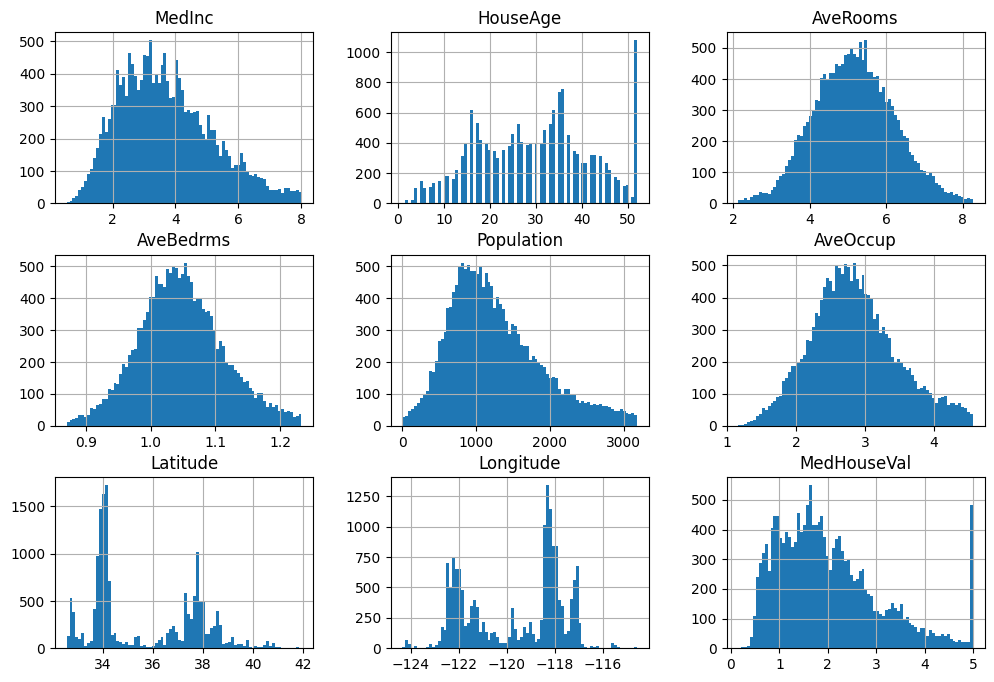

In [32]:
housing_df.hist(bins=80, figsize=(12,8))
plt.show()

### 3. Normaliser ou standardiser les données si nécessaire et séparer les données de train et test.

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. D'ABORD : Séparer les features (X) et la cible (y)
X = housing_df.drop(columns="MedHouseVal")
y = housing_df["MedHouseVal"]

# 2. ENSUITE : Diviser en train/test AVANT toute transformation
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. PUIS : Standardiser uniquement sur le train set
columns_to_standardize = ['MedInc', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']

scaler = StandardScaler()

# Fit le scaler UNIQUEMENT sur les données d'entraînement
X_train[columns_to_standardize] = scaler.fit_transform(X_train[columns_to_standardize])

# Transform le test set avec les paramètres appris sur le train
X_test[columns_to_standardize] = scaler.transform(X_test[columns_to_standardize])

# Vérification
print("="*50)
print("ENSEMBLE D'ENTRAÎNEMENT")
print("="*50)
print(f"Taille : {X_train.shape[0]} observations")
print(X_train.head())
print("\n" + "="*50)
print("ENSEMBLE DE TEST")
print("="*50)
print(f"Taille : {X_test.shape[0]} observations")
print(X_test.head())

# Vérification des statistiques (train doit avoir mean≈0, std≈1)
print("\n" + "="*50)
print("STATISTIQUES SUR LE TRAIN (après standardisation)")
print("="*50)
print(X_train[columns_to_standardize].describe())

ENSEMBLE D'ENTRAÎNEMENT
Taille : 13450 observations
         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
217   -0.508751      47.0  0.121099   0.058576   -0.649795  0.156400   
18634  1.048238      19.0  0.962291   2.233679   -0.497516  0.108665   
18016  0.663529      19.0 -0.051208   0.275823   -0.429307 -0.790636   
4236   2.923655      39.0  2.008843  -0.012964    0.003736 -0.745509   
9072  -1.147849      36.0 -0.953986   0.690044   -0.936904 -0.798212   

       Latitude  Longitude  
217       37.79    -122.21  
18634     37.05    -121.99  
18016     37.26    -121.97  
4236      34.12    -118.31  
9072      34.70    -118.14  

ENSEMBLE DE TEST
Taille : 3363 observations
         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
53    -1.671786      52.0 -1.030325   1.399633   -0.169164  0.098254   
2059  -0.470953      39.0  0.017773   0.357561   -1.000353 -0.274112   
3204   0.362301       4.0  0.038530   0.168610   -0.553034 -0.005283   
1303  -1

La standardisation a été appliquée après la division des données, selon le principe suivant :

* Fit sur train uniquement : Calcul de la moyenne (μ) et de l'écart-type (σ) exclusivement sur les 13 450 observations d'entraînement
Transform sur train et test : Application de ces mêmes paramètres (μ et σ du train) aux deux ensembles

* Variables standardisées : MedInc, AveRooms, AveBedrms, Population, AveOccup

**Pourquoi cet ordre est crucial ?**

* Prévention du data leakage : Si la standardisation était effectuée avant le split, les statistiques du test set (moyenne, écart-type) influenceraient la transformation du train set. Cela créerait une "fuite d'information" donnant une évaluation artificiellement optimiste des performances du modèle.

* Simulation des conditions de production : En production, un modèle ne connaît jamais les statistiques des nouvelles données à prédire. Il utilise les paramètres appris durant l'entraînement. Notre approche reproduit fidèlement ce scénario.

* Vérification de la standardisation :
Les statistiques sur l'ensemble d'entraînement confirment la bonne application de la transformation :

Moyenne ≈ 0

Écart-type ≈ 1

Les données sont désormais prêtes pour la phase de modélisation, avec un preprocessing rigoureux garantissant des évaluations fiables et conformes aux standards de l'industrie.